In [48]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Dataset Loading and Exploratory Data Analysis

###### The house-price dataset was loaded using pandas and inspected to understand its structure, column names, data types, and number of records.
###### Missing values and duplicate records were checked to identify data-quality problems. Descriptive statistics were calculated to understand the average, minimum, maximum, and spread of numerical features.
###### The distribution of the target variable, house price, was visualised using a histogram and box plot. These visualisations help identify skewness, unusual values, and possible price outliers before preparing the dataset for model training.

Current working directory:
c:\Users\vinay\OneDrive\Desktop\Infobyte\OIBSIP\DataAnalytics-L2-HousePredection

CSV files found:
Dataset\house_prices.csv

Dataset loaded successfully.

Dataset shape: (2000, 10)

Column names:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

First five rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB

Missing-value report:
No missing values were found.

Number of duplicate rows: 0

Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0



Categorical descriptive statistics:


C:\Users\vinay\AppData\Local\Temp\ipykernel_20284\2460540768.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


,count,unique,top,freq
Location,2000,4,Downtown,558
Condition,2000,4,Fair,521
Garage,2000,2,No,1038



Target-variable statistics:


count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64

Price skewness: -0.06


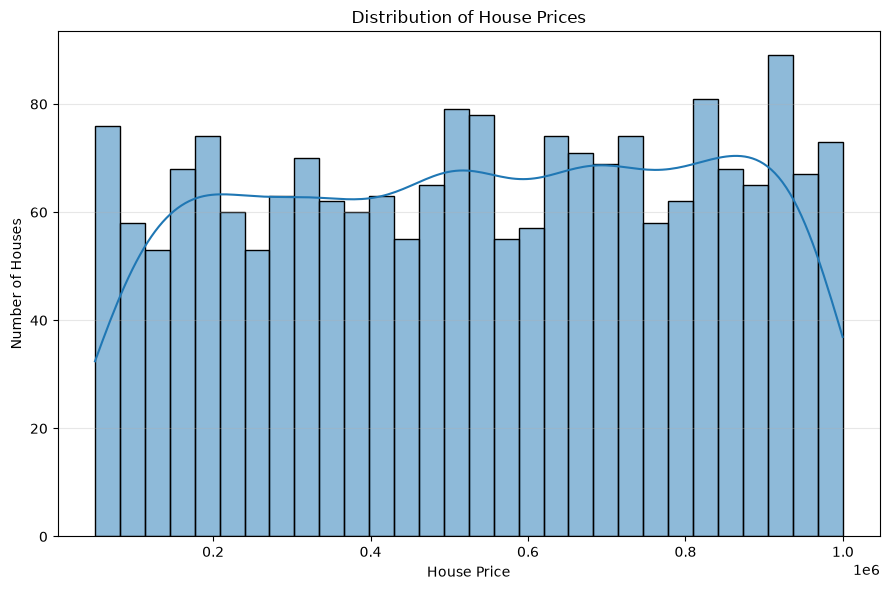

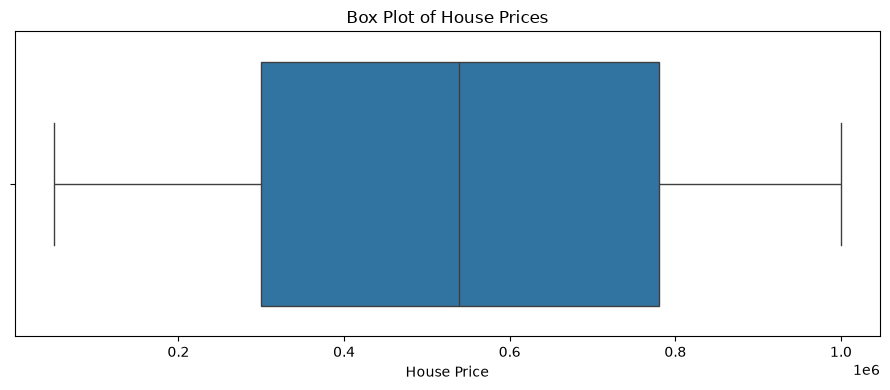

In [49]:

# --------------------------------------------------
# 1. Find CSV files
# --------------------------------------------------
print("Current working directory:")
print(os.getcwd())

csv_files = list(Path(".").rglob("*.csv"))

print("\nCSV files found:")
for file in csv_files:
    print(file)

# --------------------------------------------------
# 2. Load the dataset
# --------------------------------------------------

df = pd.read_csv("dataset/house_prices.csv")

print("\nDataset loaded successfully.")

# --------------------------------------------------
# 3. Inspect the dataset
# --------------------------------------------------
print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nDataset information:")
df.info()

# --------------------------------------------------
# 4. Check missing values
# --------------------------------------------------
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_report = missing_report[
    missing_report["Missing_Count"] > 0
].sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("\nMissing-value report:")

if missing_report.empty:
    print("No missing values were found.")
else:
    display(missing_report)

# --------------------------------------------------
# 5. Check duplicate rows
# --------------------------------------------------
duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)

# --------------------------------------------------
# 6. Descriptive statistics
# --------------------------------------------------
print("\nNumerical descriptive statistics:")
display(df.describe().T)

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

if len(categorical_columns) > 0:
    print("\nCategorical descriptive statistics:")
    display(df[categorical_columns].describe().T)

# --------------------------------------------------
# 7. Set the target variable
# Change this if your column has another name
# --------------------------------------------------
target_column = "Price"

if target_column not in df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Convert target to numeric
df[target_column] = pd.to_numeric(
    df[target_column],
    errors="coerce"
)

# Keep rows with valid price values
eda_df = df.dropna(
    subset=[target_column]
).copy()

# --------------------------------------------------
# 8. Target statistics
# --------------------------------------------------
print("\nTarget-variable statistics:")
display(eda_df[target_column].describe())

print(
    "Price skewness:",
    round(eda_df[target_column].skew(), 2)
)

# --------------------------------------------------
# 9. Price distribution
# --------------------------------------------------
plt.figure(figsize=(9, 6))

sns.histplot(
    data=eda_df,
    x=target_column,
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 10. Price box plot
# --------------------------------------------------
plt.figure(figsize=(9, 4))

sns.boxplot(
    data=eda_df,
    x=target_column
)

plt.title("Box Plot of House Prices")
plt.xlabel("House Price")
plt.tight_layout()
plt.show()

# Feature Selection for House Price Prediction

##### The target variable selected for this project is **Price**, because the main objective is to predict the selling price of a house.

##### The following features were selected as possible predictors:

###### * **Area:** Larger houses usually have higher prices because they provide more living space.
###### * **Bedrooms:** Houses with more bedrooms may have higher prices and can accommodate larger families.
###### * **Bathrooms:** More bathrooms generally increase the comfort and value of a house.
###### * **Floors:** The number of floors represents the size and structure of the property.
###### * **YearBuilt:** The construction year helps identify the age of the house. Newer houses may have higher prices because they usually require less maintenance.
###### * **Location:** House prices can vary significantly depending on the neighbourhood, accessibility, facilities, and demand.
###### * **Condition:** Houses in better condition may have higher prices than properties requiring repairs.
###### * **Garage:** The availability or size of a garage can increase the value of a property.

###### The **Id** column was excluded because it is only a unique record identifier and does not describe the physical or market characteristics of the house.

##### Therefore, Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, and Garage were selected as input features, while Price was selected as the target variable.




In [50]:
# Target variable that the model will predict
target_column = "Price"

# Features selected for house-price prediction
selected_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage"
]

# Create input features X
X = df[selected_features].copy()

# Create target variable y
y = df[target_column].copy()

print("Selected predictor features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(target_column)

print("\nInput feature shape:", X.shape)
print("Target shape:", y.shape)


# Select numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Select categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Selected predictor features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']

Target variable:
Price

Input feature shape: (2000, 8)
Target shape: (2000,)
Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']


C:\Users\vinay\AppData\Local\Temp\ipykernel_20284\3437758598.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


# Handling Missing Values and Encoding Categorical Features

###### Missing values were handled before training the house-price prediction model. Numerical features were prepared using median imputation, while categorical features were prepared using the most frequent value.

###### Categorical columns such as Location and Condition cannot be directly used by a Linear Regression model. Therefore, One-Hot Encoding was used to convert each category into separate numerical columns.

###### A preprocessing pipeline was created to apply the correct transformation to numerical and categorical features. This prevents errors and prepares the dataset for model training.


In [51]:

# --------------------------------------------------
# 1. Check missing values in predictor features
# --------------------------------------------------

missing_report = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),
    "Missing_Percentage": (
        X.isnull().mean() * 100
    ).round(2)
})

missing_report = missing_report[
    missing_report["Missing_Count"] > 0
].sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("\nMissing-value report:")

if missing_report.empty:
    print("No missing values were found in predictor features.")
else:
    display(missing_report)


# --------------------------------------------------
# 2. Identify numerical and categorical features
# --------------------------------------------------

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


# --------------------------------------------------
# 3. Numerical preprocessing pipeline
# --------------------------------------------------
# Missing numerical values are replaced with the median.

numerical_pipeline = Pipeline(
    steps=[
        (
            "numeric_imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# --------------------------------------------------
# 4. Create One-Hot Encoder
# --------------------------------------------------
# handle_unknown="ignore" prevents errors when a new
# category appears in the test data.

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:
    # This works with older scikit-learn versions
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


# --------------------------------------------------
# 5. Categorical preprocessing pipeline
# --------------------------------------------------
# Missing categorical values are replaced with the
# most frequently occurring value.
# Categories are then converted into numerical columns.

categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot_encoder",
            one_hot_encoder
        )
    ]
)


# --------------------------------------------------
# 6. Combine both preprocessing pipelines
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("\nPreprocessing pipeline created successfully.")
print("Missing numerical values will be replaced with the median.")
print("Missing categorical values will be replaced with the most frequent value.")
print("Categorical features will be converted using One-Hot Encoding.")


Missing-value report:
No missing values were found in predictor features.

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']

Preprocessing pipeline created successfully.
Missing numerical values will be replaced with the median.
Missing categorical values will be replaced with the most frequent value.
Categorical features will be converted using One-Hot Encoding.


# Correlation Analysis of House Price Features

###### A correlation heatmap was created to examine the relationship between the selected house features and the target variable, Price.

###### A positive correlation indicates that the house price may increase when the feature value increases, while a negative correlation indicates that the price may decrease. Features with correlation values closer to +1 or −1 have a stronger linear relationship with house price.

###### Categorical features such as Location, Condition, and Garage were converted into numerical columns using One-Hot Encoding before calculating correlation. The heatmap helps identify the features that may be most useful for predicting house prices.

##### Correlation shows association but does not prove that a feature directly causes a change in house price.



Categorical columns:
['Location', 'Condition', 'Garage']

Columns after One-Hot Encoding:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']

Total missing values after cleaning: 0

Correlation matrix created successfully.


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542,-0.017328,0.003404,0.000010,0.012805,0.001289,-0.003387,-0.003441
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471,-0.011276,-0.010409,0.025640,0.002541,-0.008847,0.010673,-0.041713
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737,-0.020028,-0.000904,-0.007326,-0.029646,0.021735,0.013355,0.004057
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890,-0.007149,-0.009907,0.014640,-0.000864,0.001462,0.017469,-0.004635
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845,-0.009179,-0.004632,-0.029859,-0.039087,0.022457,0.020892,-0.011703


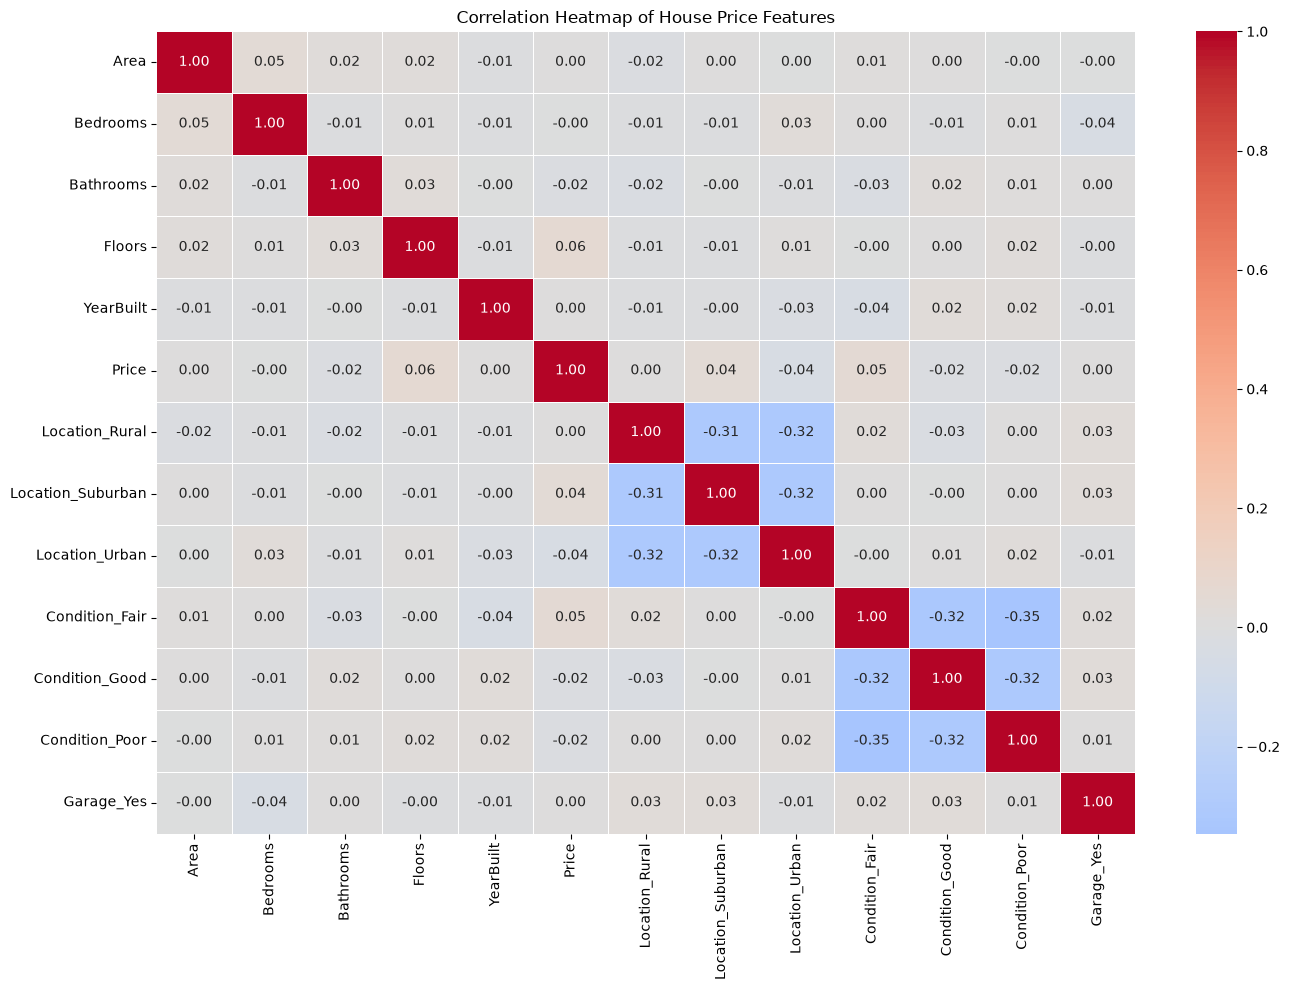


Features most strongly correlated with Price:


,Correlation_with_Price
Floors,0.055890
Condition_Fair,0.049218
Location_Suburban,0.040303
Location_Urban,-0.038312
Condition_Poor,-0.018437
Condition_Good,-0.017179
Bathrooms,-0.015737
YearBuilt,0.004845
Bedrooms,-0.003471
Garage_Yes,0.002842



Top 10 features correlated with Price:


,Correlation_with_Price
Floors,0.055890
Condition_Fair,0.049218
Location_Suburban,0.040303
Location_Urban,-0.038312
Condition_Poor,-0.018437
Condition_Good,-0.017179
Bathrooms,-0.015737
YearBuilt,0.004845
Bedrooms,-0.003471
Garage_Yes,0.002842


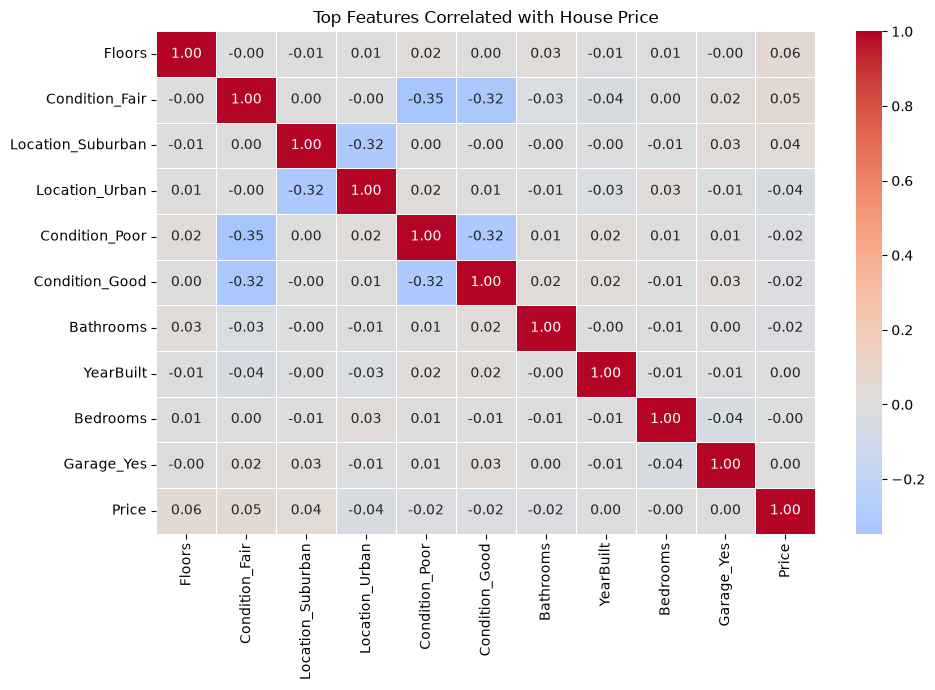

In [ ]:

# --------------------------------------------------
# 1. Select features and target variable
# --------------------------------------------------

selected_columns = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Location",
    "Condition",
    "Garage",
    "Price"
]


# --------------------------------------------------
# 2. Check whether all required columns exist
# --------------------------------------------------

missing_columns = [
    column
    for column in selected_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These columns were not found: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )


# --------------------------------------------------
# 3. Create a copy for correlation analysis
# --------------------------------------------------

correlation_df = df[selected_columns].copy()


# --------------------------------------------------
# 4. Convert numerical columns into numeric format
# --------------------------------------------------

numeric_columns = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "Price"
]

for column in numeric_columns:
    correlation_df[column] = pd.to_numeric(
        correlation_df[column],
        errors="coerce"
    )


# --------------------------------------------------
# 5. Identify categorical columns
# --------------------------------------------------

categorical_columns = correlation_df.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)


# --------------------------------------------------
# 6. Apply One-Hot Encoding
# --------------------------------------------------

correlation_encoded = pd.get_dummies(
    correlation_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("\nColumns after One-Hot Encoding:")
print(correlation_encoded.columns.tolist())


# --------------------------------------------------
# 7. Convert all remaining columns into numeric format
# --------------------------------------------------

for column in correlation_encoded.columns:
    correlation_encoded[column] = pd.to_numeric(
        correlation_encoded[column],
        errors="coerce"
    )


# --------------------------------------------------
# 8. Handle missing values
# --------------------------------------------------

correlation_encoded = correlation_encoded.fillna(
    correlation_encoded.median(numeric_only=True)
)

print(
    "\nTotal missing values after cleaning:",
    correlation_encoded.isnull().sum().sum()
)


# --------------------------------------------------
# 9. Calculate the correlation matrix
# --------------------------------------------------

correlation_matrix = correlation_encoded.corr()

print("\nCorrelation matrix created successfully.")

display(correlation_matrix.head())


# --------------------------------------------------
# 10. Create the complete correlation heatmap
# --------------------------------------------------

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of House Price Features")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 11. Rank features by correlation strength with Price
# --------------------------------------------------

correlation_strength = (
    correlation_matrix["Price"]
    .drop("Price")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("\nFeatures most strongly correlated with Price:")

display(
    correlation_strength
    .to_frame(name="Correlation_with_Price")
)


# --------------------------------------------------
# 12. Display the top 10 most correlated features
# --------------------------------------------------

top_correlations = correlation_strength.head(10)

print("\nTop 10 features correlated with Price:")

display(
    top_correlations
    .to_frame(name="Correlation_with_Price")
)


# --------------------------------------------------
# 13. Create a smaller heatmap using top features
# --------------------------------------------------

top_features = top_correlations.index.tolist()
top_columns = top_features + ["Price"]

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_encoded[top_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Top Features Correlated with House Price")
plt.tight_layout()
plt.show()

# Train-Test Split

###### The house-price dataset was divided into training and testing sets using an 80/20 ratio.

###### The training set contains 80% of the data and is used to train the Linear Regression model. The testing set contains the remaining 20% and is used to evaluate the model on unseen house data.

###### A random state of 42 was used to produce the same data split whenever the notebook is executed. This makes the model results reproducible.


In [53]:

# Create input features
X = df[selected_features].copy()

# Create the target variable
y = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

# --------------------------------------------------
# 3. Remove rows with missing Price values
# --------------------------------------------------

valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

# --------------------------------------------------
# 4. Split the dataset
# 80% training data and 20% testing data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# --------------------------------------------------
# 5. Display split results
# --------------------------------------------------

print("\nTrain-test split completed successfully.")

print("\nComplete feature data:", X.shape)
print("Complete target data:", y.shape)

print("\nTraining features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)


Train-test split completed successfully.

Complete feature data: (2000, 8)
Complete target data: (2000,)

Training features: (1600, 8)
Testing features: (400, 8)

Training target: (1600,)
Testing target: (400,)


In [54]:

#--------------------------------------------------
# 1. Remove rows with missing target values
# --------------------------------------------------

valid_rows = y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)


# --------------------------------------------------
# 2. Identify numerical and categorical features
# --------------------------------------------------

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["str", "category", "bool"]
).columns.tolist()

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


# --------------------------------------------------
# 3. Create numerical preprocessing pipeline
# --------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "numeric_imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# --------------------------------------------------
# 4. Create categorical preprocessing pipeline
# --------------------------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# --------------------------------------------------
# 5. Combine preprocessing steps
# --------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# --------------------------------------------------
# 6. Split data: 80% training and 20% testing
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# --------------------------------------------------
# 7. Create the complete model pipeline
# --------------------------------------------------

linear_regression_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ]
)


# --------------------------------------------------
# 8. Train the Linear Regression model
# --------------------------------------------------

linear_regression_model.fit(
    X_train,
    y_train
)

print("\nLinear Regression model trained successfully.")


 # --------------------------------------------------
 # 9. Predict house prices using testing data
 # --------------------------------------------------
print("---------------------------------------------")
print("First Five Actual Prices & Predicted Prices:")
print("---------------------------------------------")
# Create a comparison table
prediction_results = pd.DataFrame({
    "Actual_Price": y_test.to_numpy(),
    "Predicted_Price": y_pred
})

# Calculate the prediction difference
prediction_results["Difference"] = (
    prediction_results["Actual_Price"]
    - prediction_results["Predicted_Price"]
)

display(prediction_results.head(5))


Input feature shape: (2000, 8)
Target shape: (2000,)

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

Categorical features:
['Location', 'Condition', 'Garage']

Training data: (1600, 8)
Testing data: (400, 8)

Linear Regression model trained successfully.
---------------------------------------------
First Five Actual Prices & Predicted Prices:
---------------------------------------------


,Actual_Price,Predicted_Price,Difference
0,514764,521988.221898,-7224.221898
1,694256,549119.311967,145136.688033
2,66375,487101.222356,-420726.222356
3,650243,539752.743993,110490.256007
4,223285,553242.248725,-329957.248725


# Evaluation of the Linear Regression Model

###### The Linear Regression model was evaluated using MSE, RMSE, and R² score.

###### MSE and RMSE measure the difference between actual and predicted house prices. Lower values indicate better predictions.

###### R² score shows how well the model explains house-price variation. A value closer to 1 indicates better model performance.


In [55]:

# --------------------------------------------------
# Display Mean Squared Error & Root Mean Squared Error & R-squared score & evaluation results
# --------------------------------------------------
print("Linear Regression Model Evaluation")

evaluation_results = pd.DataFrame({
    "Evaluation Metric": [
        "Mean Squared Error",
        "Root Mean Squared Error",
        "R² Score"
    ],
    "Result": [
        mse,
        rmse,
        r2
    ]
})

display(evaluation_results)

Linear Regression Model Evaluation


,Evaluation Metric,Result
0,Mean Squared Error,7.832132e+10
1,Root Mean Squared Error,2.798595e+05
2,R² Score,-6.715988e-03


# Actual Prices vs Predicted Prices

###### A scatter plot was created to compare the actual house prices with the prices predicted by the Linear Regression model.

###### Each point represents one house. If the points are close to the diagonal line, the model predictions are accurate. Points far from the line indicate larger prediction errors.


,Actual_Price,Predicted_Price
0,514764,521988.221898
1,694256,549119.311967
2,66375,487101.222356
3,650243,539752.743993
4,223285,553242.248725
5,468127,521375.920258
6,513002,523320.180806
7,911525,578133.643533
8,723265,545899.647385
9,339416,577368.699406


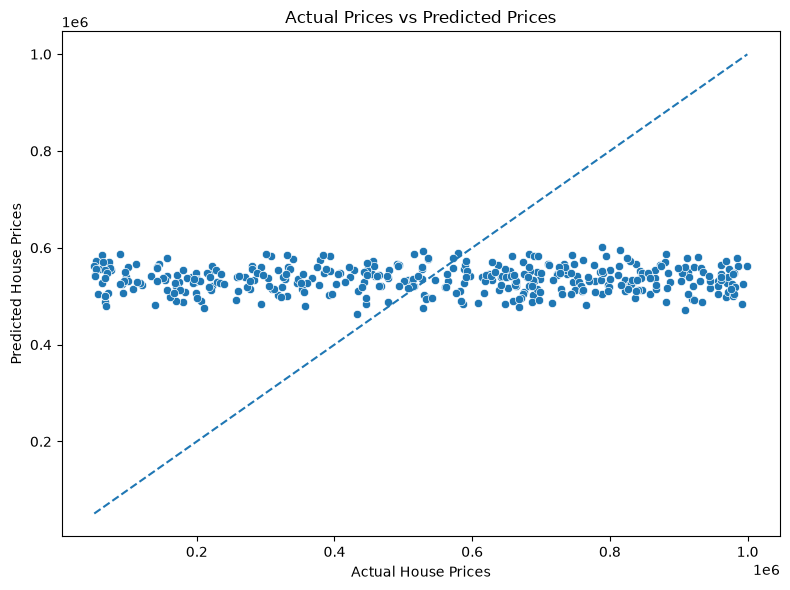

In [56]:

# Create the scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

# Create a diagonal reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

comparison_df = pd.DataFrame({
    "Actual_Price": y_test.to_numpy(),
    "Predicted_Price": y_pred
})

display(comparison_df.head(10))

# Add title and labels
plt.title("Actual Prices vs Predicted Prices")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.tight_layout()

# Show the plot
plt.show()



# Residual Analysis

###### Residuals represent the difference between the actual and predicted house prices.

###### A residual plot was created to check whether the prediction errors were randomly distributed around zero. Randomly scattered points without a clear pattern indicate that the Linear Regression model is suitable.

###### A curved pattern, funnel shape, or systematic arrangement may indicate that the model is missing important relationships or that the data does not fully satisfy the assumptions of Linear Regression.


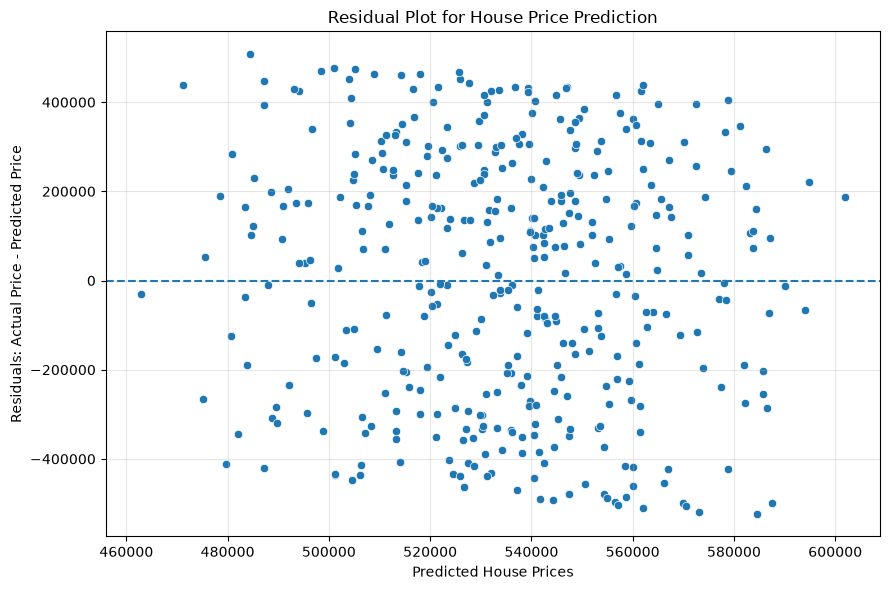

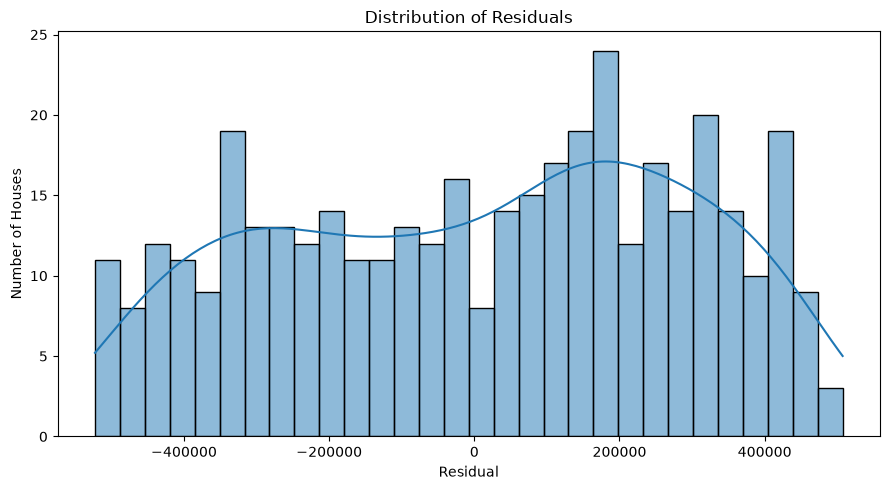

Residual Summary
----------------
Mean residual: 8623.22
Minimum residual: -522578.66
Maximum residual: 507380.46


In [57]:

# Calculate residuals
residuals = y_test.to_numpy() - y_pred

# Create residual plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

# Add horizontal zero-error line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot for House Price Prediction")
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals: Actual Price - Predicted Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Display the distribution of residuals
plt.figure(figsize=(9, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

# Residual distribution
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# Residual summary
print("Residual Summary")
print("----------------")
print("Mean residual:", round(np.mean(residuals), 2))
print("Minimum residual:", round(np.min(residuals), 2))
print("Maximum residual:", round(np.max(residuals), 2))

# Linear Regression Coefficient Analysis

###### The coefficients of the trained Linear Regression model were analysed to understand how each feature affected the predicted house price.

###### A positive coefficient indicates that the feature increases the predicted price, while a negative coefficient indicates that it decreases the predicted price, assuming the other features remain unchanged.

###### The features with the largest positive and negative coefficients were identified to understand which house characteristics had the strongest impact on the model predictions.


,Feature,Coefficient
0,Floors,23727.983633
1,Condition_Fair,20279.424861
2,Location_Suburban,11484.336584
3,Location_Rural,1289.888789
4,Garage_Yes,1186.765289
5,Condition_Poor,269.385945
6,YearBuilt,117.613885
7,Bedrooms,76.784827
8,Area,-0.575754
9,Location_Downtown,-27.653231


Features with the highest positive impact:


,Feature,Coefficient
0,Floors,23727.983633
1,Condition_Fair,20279.424861
2,Location_Suburban,11484.336584
3,Location_Rural,1289.888789
4,Garage_Yes,1186.765289
5,Condition_Poor,269.385945
6,YearBuilt,117.613885
7,Bedrooms,76.784827


Features with the highest negative impact:


,Feature,Coefficient
14,Condition_Good,-16744.927821
13,Location_Urban,-12746.572142
12,Bathrooms,-9662.248234
11,Condition_Excellent,-3803.882985
10,Garage_No,-1186.765289
9,Location_Downtown,-27.653231
8,Area,-0.575754


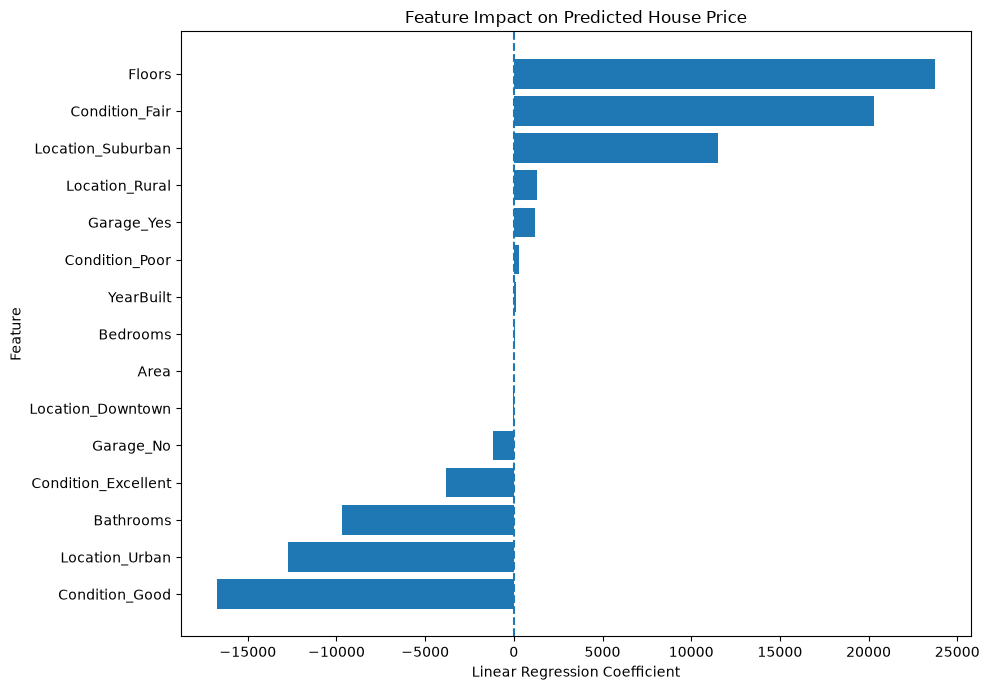

Model intercept: 283538.83


In [58]:
# Import pandas
import pandas as pd

# Get the fitted preprocessing step
fitted_preprocessor = linear_regression_model.named_steps[
    "preprocessing"
]

# Get the fitted Linear Regression model
fitted_regression = linear_regression_model.named_steps[
    "linear_regression"
]

# Get feature names after One-Hot Encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Make the feature names easier to read
clean_feature_names = [
    name
    .replace("numerical__", "")
    .replace("categorical__", "")
    for name in feature_names
]

# Get model coefficients
coefficients = fitted_regression.coef_

# Create a coefficient DataFrame
coefficient_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Coefficient": coefficients
})

# Sort coefficients from highest to lowest
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_df)



# Features with the highest positive impact
positive_coefficients = (
    coefficient_df[
        coefficient_df["Coefficient"] > 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=False
    )
    .head(10)
)

print("Features with the highest positive impact:")
display(positive_coefficients)

# Features with the highest negative impact
negative_coefficients = (
    coefficient_df[
        coefficient_df["Coefficient"] < 0
    ]
    .sort_values(
        by="Coefficient",
        ascending=True
    )
    .head(10)
)

print("Features with the highest negative impact:")
display(negative_coefficients)

# Coefficient bar chart
# Combine important positive and negative coefficients
important_coefficients = pd.concat([
    negative_coefficients,
    positive_coefficients
]).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    important_coefficients["Feature"],
    important_coefficients["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Feature Impact on Predicted House Price")
plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Model intercept
print(
    "Model intercept:",
    round(fitted_regression.intercept_, 2)
)

# Comparison of Linear Regression, Ridge and Lasso Models

###### Linear Regression was compared with Ridge and Lasso regularised regression models.

###### Ridge Regression reduces large coefficient values and can improve model stability when features are correlated. Lasso Regression can reduce some coefficients to zero, which may help identify less important features.

###### The models were compared using MSE, RMSE, and R² score. The model with lower error values and a higher R² score was considered the better-performing model.


In [ ]:
# --------------------------------------------------
# Linear Regression vs Ridge vs Lasso
# --------------------------------------------------

from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Identify numerical and categorical features
numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["str", "object", "category", "bool"]
).columns.tolist()


# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )
    )
])


# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# Models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(
        alpha=1.0,
        max_iter=10000
    )
}


# Train and evaluate models
results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Train model
    pipeline.fit(X_train, y_train)

    # Predict prices
    predictions = pipeline.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })


# Create model comparison table
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)
display(comparison_df)


# Display the best model
print("Best model:", comparison_df.loc[0, "Model"])
print(
    "Best R² score:",
    round(comparison_df.loc[0, "R² Score"], 4)
)

,Model,MSE,RMSE,R² Score
0,Ridge Regression,7.832132e+10,279859.465447,-0.006716
1,Lasso Regression,7.832132e+10,279859.472849,-0.006716
2,Linear Regression,7.832147e+10,279859.725838,-0.006718


Best model: Ridge Regression
Best R² score: -0.0067


# Project Conclusion

##### This project developed an end-to-end house price prediction system using Linear Regression. The dataset was explored, cleaned, and prepared by handling missing values and converting categorical features using One-Hot Encoding.

##### Important predictors such as Area, Bedrooms, Bathrooms, Location, YearBuilt, Condition, and Garage were used to train the model. The dataset was divided into 80% training data and 20% testing data.

##### The model was evaluated using MSE, RMSE, and R² score. Actual-versus-predicted and residual plots were used to understand prediction accuracy and model behaviour. Coefficient analysis helped identify the features that had positive and negative effects on house prices.

##### Linear Regression was also compared with Ridge and Lasso Regression using the same evaluation metrics. Overall, this project demonstrated how regression models can be used to analyse housing data, predict prices, and interpret the factors that influence property value.
